# RL Agent Training & Decision Analysis
**ASD Intervention System — PPO Policy Training**


## 1. Setup

In [1]:
import sys
from pathlib import Path

BACKEND_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(BACKEND_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList

from app.rl.environment import ASDInterventionEnv
from app.rl.action_space import decode_action, ACTION_SPACE_CONFIG
from app.rl.reward_calculator import calculate_reward
from app.rl.training.hyperparameters import get_ppo_config
from app.synthetic_users.generator import load_all_profiles

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'

FIGURES_DIR = BACKEND_DIR / 'data' / 'evaluation' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = BACKEND_DIR / 'model_store'
DATA_DIR = BACKEND_DIR / 'data' / 'synthetic_users'

print('Setup complete')
print(f'Backend dir : {BACKEND_DIR}')
print(f'Figures dir : {FIGURES_DIR}')
print(f'Model dir   : {MODEL_DIR}')

Setup complete
Backend dir : /Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend
Figures dir : /Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend/data/evaluation/figures
Model dir   : /Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend/model_store


## 2. Custom Logging Callback


In [2]:
class TrainingLogger(BaseCallback):

    def __init__(self, log_freq: int = 1000):
        super().__init__(verbose=0)
        self.log_freq = log_freq
        self.records: list[dict] = []
        self._last_log_step = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_log_step < self.log_freq:
            return True
        self._last_log_step = self.num_timesteps

        logger = self.model.logger
        def _get(key, default=float('nan')):
            try:
                return float(logger.name_to_value.get(key, default))
            except Exception:
                return default

        self.records.append({
            'timestep'    : self.num_timesteps,
            'policy_loss' : _get('train/policy_gradient_loss'),
            'value_loss'  : _get('train/value_loss'),
            'entropy_loss': _get('train/entropy_loss'),
            'approx_kl'   : _get('train/approx_kl'),
            'clip_fraction': _get('train/clip_fraction'),
        })
        return True

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.records)


class EvalLogger(BaseCallback):
    """Records mean reward and success rate at each evaluation checkpoint."""

    def __init__(self):
        super().__init__(verbose=0)
        self.records: list[dict] = []

    def _on_step(self) -> bool:
        logger = self.model.logger
        def _get(key, default=float('nan')):
            try:
                return float(logger.name_to_value.get(key, default))
            except Exception:
                return default

        mean_reward = _get('eval/mean_reward')
        if not np.isnan(mean_reward):
            self.records.append({
                'timestep'   : self.num_timesteps,
                'mean_reward': mean_reward,
                'mean_ep_len': _get('eval/mean_ep_length'),
            })
        return True

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.records)


print('Callback classes defined')

Callback classes defined


## 3. Train the Model

In [3]:
TIMESTEPS = 100_000
SEED = 42

config = get_ppo_config()

# Load synthetic user profiles
train_profiles = load_all_profiles(str(DATA_DIR), split='train')
test_profiles  = load_all_profiles(str(DATA_DIR), split='test')
print(f'Train profiles: {len(train_profiles)}  |  Test profiles: {len(test_profiles)}')

# Build parallel training environments
n_envs = min(config['n_envs'], len(train_profiles))
train_env = DummyVecEnv([
    (lambda p=train_profiles[i], s=SEED+i: ASDInterventionEnv(p, seed=s))
    for i in range(n_envs)
])
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

# Evaluation environment
n_eval = min(10, len(test_profiles))
eval_env = DummyVecEnv([
    (lambda p=test_profiles[i], s=SEED+1000+i: ASDInterventionEnv(p, seed=s))
    for i in range(n_eval)
])
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=True,
                        clip_obs=10.0, training=False)

# Output directories
MODEL_DIR.mkdir(parents=True, exist_ok=True)
(MODEL_DIR / 'checkpoints').mkdir(exist_ok=True)
(MODEL_DIR / 'best').mkdir(exist_ok=True)

# Callbacks
training_logger = TrainingLogger(log_freq=500)
eval_logger     = EvalLogger()

eval_cb = EvalCallback(
    eval_env,
    best_model_save_path=str(MODEL_DIR / 'best'),
    eval_freq=config['eval_freq'] // n_envs,
    n_eval_episodes=config['n_eval_episodes'],
    deterministic=True,
    callback_after_eval=eval_logger,
)

# Build and train PPO model
model = PPO(
    policy='MlpPolicy',
    env=train_env,
    learning_rate=config['learning_rate'],
    n_steps=config['n_steps'],
    batch_size=config['batch_size'],
    n_epochs=config['n_epochs'],
    gamma=config['gamma'],
    gae_lambda=config['gae_lambda'],
    clip_range=config['clip_range'],
    ent_coef=config['ent_coef'],
    vf_coef=config['vf_coef'],
    max_grad_norm=config['max_grad_norm'],
    seed=SEED,
    tensorboard_log=str(MODEL_DIR / 'tensorboard'),
    verbose=1,
)

print(f'\nPolicy network architecture:')
print(model.policy)

print(f'\nStarting training for {TIMESTEPS:,} timesteps...')
model.learn(
    total_timesteps=TIMESTEPS,
    callback=CallbackList([training_logger, eval_cb]),
    tb_log_name='ppo_asd',
)

# Save
model.save(str(MODEL_DIR / 'ppo_asd_final'))
train_env.save(str(MODEL_DIR / 'vec_normalize.pkl'))
print('\nModel saved.')

Train profiles: 40  |  Test profiles: 10
Using cpu device

Policy network architecture:
ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=60, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=60, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=225, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)

Starting training for 100,000 timesteps..

/Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend/.venv/lib/python3.13/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


------------------------------------------
| time/                   |              |
|    fps                  | 7111         |
|    iterations           | 7            |
|    time_elapsed         | 1            |
|    total_timesteps      | 7168         |
| train/                  |              |
|    approx_kl            | 0.0022927616 |
|    clip_fraction        | 0.00228      |
|    clip_range           | 0.2          |
|    entropy_loss         | -5.41        |
|    explained_variance   | 0.358        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0278       |
|    n_updates            | 18           |
|    policy_gradient_loss | -0.0255      |
|    value_loss           | 0.247        |
------------------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 7208         |
|    iterations           | 8            |
|    time_elapsed         | 1            |
|    total_

## 4. Load a Pre-trained Model


In [2]:

# from stable_baselines3.common.vec_env import VecNormalize
# from stable_baselines3 import PPO
#
# # Rebuild a dummy environment just for VecNormalize to attach to
# test_profiles = load_all_profiles(str(DATA_DIR), split='test')
# _dummy_env = DummyVecEnv([
#     lambda p=test_profiles[0]: ASDInterventionEnv(p, seed=99)
# ])
#
# train_env = VecNormalize.load(str(MODEL_DIR / 'vec_normalize.pkl'), _dummy_env)
# train_env.training = False
#
# model = PPO.load(str(MODEL_DIR / 'ppo_asd_final'), env=train_env)
# print('Model loaded from', MODEL_DIR)


## 5. Training Curves

Training log rows : 199
Eval log rows     : 0


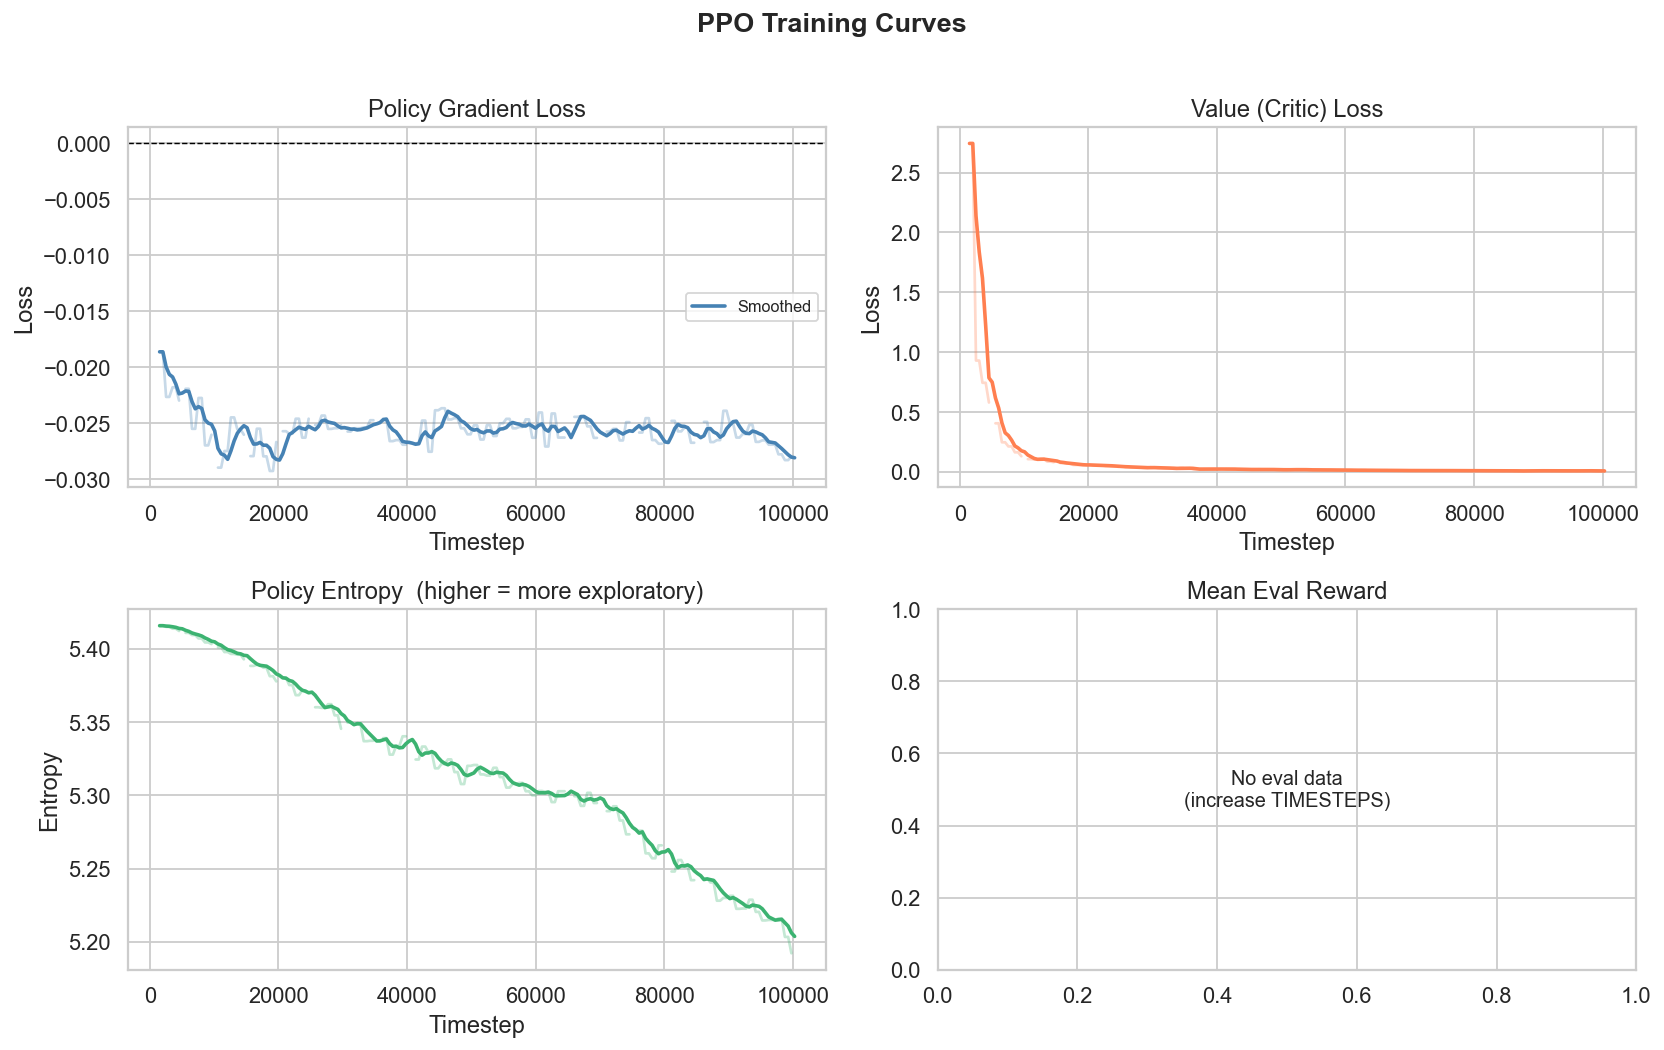

Saved /Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend/data/evaluation/figures/training_curves.pdf


In [4]:
df_train = training_logger.to_dataframe()
df_eval  = eval_logger.to_dataframe()

print(f'Training log rows : {len(df_train)}')
print(f'Eval log rows     : {len(df_eval)}')

if len(df_train) == 0:
    print('No training data yet — run Section 3 first, or load a model from Section 4.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle('PPO Training Curves', fontsize=15, fontweight='bold', y=1.01)

    def smooth(series, w=5):
        return series.rolling(w, min_periods=1).mean()

    # Policy loss
    ax = axes[0, 0]
    ax.plot(df_train['timestep'], df_train['policy_loss'], alpha=0.3, color='steelblue')
    ax.plot(df_train['timestep'], smooth(df_train['policy_loss']),
            color='steelblue', linewidth=2, label='Smoothed')
    ax.set_title('Policy Gradient Loss')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Loss')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=9)

    # Value loss
    ax = axes[0, 1]
    ax.plot(df_train['timestep'], df_train['value_loss'], alpha=0.3, color='coral')
    ax.plot(df_train['timestep'], smooth(df_train['value_loss']),
            color='coral', linewidth=2)
    ax.set_title('Value (Critic) Loss')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Loss')

    # Entropy : how exploratory the policy is
    ax = axes[1, 0]
    ax.plot(df_train['timestep'], df_train['entropy_loss'].abs(), alpha=0.3, color='mediumseagreen')
    ax.plot(df_train['timestep'], smooth(df_train['entropy_loss'].abs()),
            color='mediumseagreen', linewidth=2)
    ax.set_title('Policy Entropy  (higher = more exploratory)')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Entropy')

    # Eval reward
    ax = axes[1, 1]
    if len(df_eval) > 0:
        ax.plot(df_eval['timestep'], df_eval['mean_reward'],
                color='darkorange', linewidth=2, marker='o', markersize=4)
        ax.set_title('Mean Eval Reward (held-out test users)')
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Mean Episode Reward')
    else:
        ax.text(0.5, 0.5, 'No eval data\n(increase TIMESTEPS)', ha='center', va='center',
                transform=ax.transAxes, fontsize=11)
        ax.set_title('Mean Eval Reward')

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'training_curves.png')
    fig.savefig(FIGURES_DIR / 'training_curves.pdf')
    plt.show()
    print(f'Saved {FIGURES_DIR}/training_curves.pdf')

## 6. Simulate a Full User Session

In [5]:
N_STEPS = 20      # number of scenarios to simulate
PROFILE_IDX = 0   # which test-set profile to use (0 = first)

profile = test_profiles[PROFILE_IDX]
print(f'Simulating profile: {profile.id}')
print(f'  Age              : {profile.age:.1f}')
print(f'  Severity         : {profile.severity}  (1=mild, 2=moderate, 3=severe)')
print(f'  Learning rate    : {profile.learning_rate:.2f}')
print(f'  Frust. tolerance : {profile.frustration_tolerance:.2f}')

# Rule-based difficulty delta — mirrors _rule_based_delta() in app/api/routes/scenarios.py.
# The deployed API never uses the model's raw difficulty_delta; it always derives the
# difficulty adjustment from the rolling last-5 success rate so the simulation must
# do the same.
def _rule_based_delta(last_5: list) -> int:
    if not last_5:
        return 0
    rolling = sum(last_5) / len(last_5)
    if rolling >= 0.8:
        return 1
    if rolling <= 0.3:
        return -1
    return 0

# Create a single (non-vectorised) env for step-by-step recording
env = ASDInterventionEnv(profile, seed=SEED)
obs, _ = env.reset()

# Track difficulty with rule-based logic (matches calculate_difficulty() in the API)
sim_difficulty: int = env._current_difficulty
last_5_success: list = []

session_records = []

for step in range(N_STEPS):
    # Normalise observation using training statistics
    obs_norm = train_env.normalize_obs(obs.reshape(1, -1)).flatten()

    # Agent predicts action — used for scenario_type and complexity only
    # (difficulty is determined by the rule-based function below, not the model)
    action_arr, _ = model.predict(obs_norm.reshape(1, -1), deterministic=True)
    action_idx    = int(action_arr[0]) if hasattr(action_arr, '__len__') else int(action_arr)
    decoded       = decode_action(action_idx)

    # Step the environment
    obs, reward, terminated, truncated, info = env.step(action_idx)

    emotions = info['emotions']
    task_completed = info['task_completed']

    # Rule-based difficulty delta (mirrors deployed API — ignores model's raw delta)
    difficulty_delta = _rule_based_delta(last_5_success)

    # Apply delta with clamp [1, 5] — matches calculate_difficulty() in the API
    sim_difficulty = max(1, min(5, sim_difficulty + difficulty_delta))

    # Update rolling last-5 success list
    last_5_success.append(1.0 if task_completed else 0.0)
    if len(last_5_success) > 5:
        last_5_success.pop(0)

    # Reward breakdown (40 / 30 / 30)
    task_r    = 1.0 if task_completed else -0.01
    engage_r  = emotions['engagement']
    emotion_r = (1.0 - emotions['frustration']) * 0.5 + emotions['confidence'] * 0.5

    session_records.append({
        'step'              : step + 1,
        'scenario'          : decoded['action_type'],
        'difficulty_delta'  : difficulty_delta,
        'difficulty'        : sim_difficulty,
        'reinforcement'     : decoded['reinforcement_mode'],
        'complexity'        : decoded['complexity_level'],
        'task_completed'    : task_completed,
        'frustration'       : emotions['frustration'],
        'engagement'        : emotions['engagement'],
        'confidence'        : emotions['confidence'],
        'reward'            : reward,
        'reward_task'       : 0.4 * task_r,
        'reward_engagement' : 0.3 * engage_r,
        'reward_emotion'    : 0.3 * emotion_r,
    })

    if terminated or truncated:
        break

df_session = pd.DataFrame(session_records)
print(f'\nSession complete — {len(df_session)} steps')
print(f'Success rate : {df_session["task_completed"].mean():.1%}')
print(f'Mean reward  : {df_session["reward"].mean():.3f}')
df_session[['step', 'scenario', 'difficulty', 'difficulty_delta',
            'task_completed', 'frustration', 'engagement', 'reward']].head(20)


Simulating profile: user_040
  Age              : 6.9
  Severity         : 1  (1=mild, 2=moderate, 3=severe)
  Learning rate    : 0.38
  Frust. tolerance : 0.23

Session complete — 20 steps
Success rate : 80.0%
Mean reward  : 0.728


,step,scenario,difficulty,difficulty_delta,task_completed,frustration,engagement,reward
0,1,emotion_recognition,3,0,True,0.0,1.000000,0.932800
1,2,sharing,4,1,True,0.0,0.586340,0.794307
2,3,emotion_recognition,5,1,False,0.7,1.000000,0.341000
3,4,emotion_recognition,5,0,True,0.0,1.000000,0.928048
4,5,sharing,5,0,True,0.0,0.525346,0.777029
5,6,emotion_recognition,5,1,True,0.1,1.000000,0.878323
6,7,sharing,5,1,True,0.0,0.560212,0.795127
7,8,sharing,5,1,True,0.1,0.588449,0.750584
8,9,emotion_recognition,5,1,True,0.0,1.000000,0.923932
9,10,sharing,5,1,True,0.0,0.562216,0.796528


## 7. Difficulty Trajectory

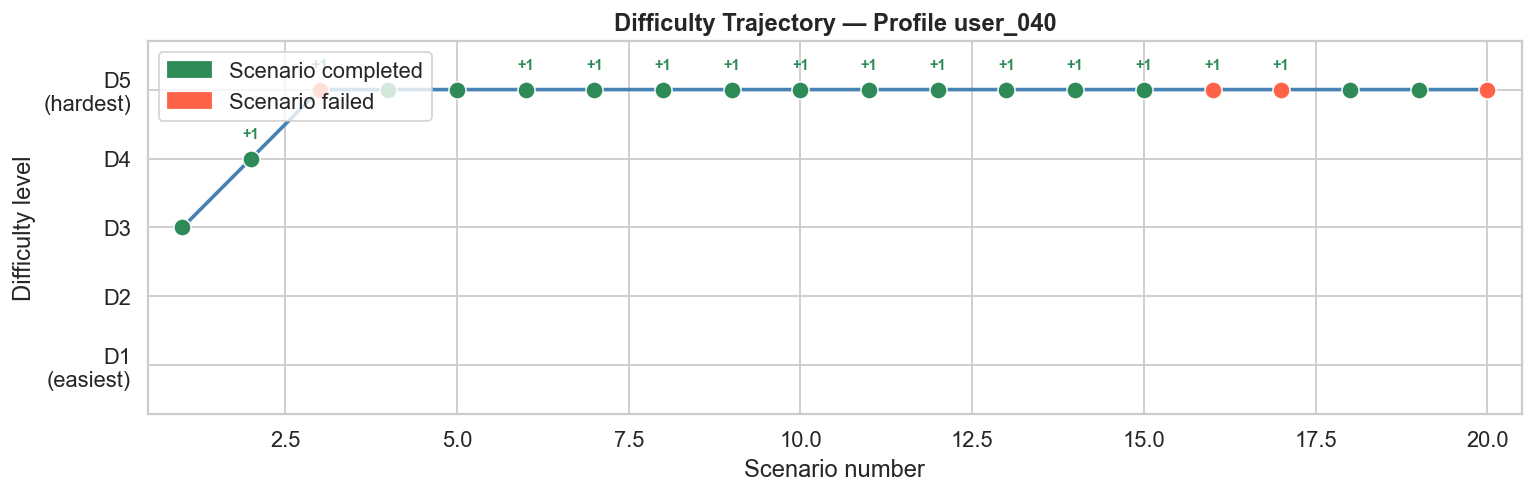

Saved -> /Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend/data/evaluation/figures/difficulty_trajectory.pdf


In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

steps = df_session['step'].values
diffs = df_session['difficulty'].values
deltas = df_session['difficulty_delta'].values
successes = df_session['task_completed'].values

# Line
ax.plot(steps, diffs, color='steelblue', linewidth=2, zorder=1)

# Colour outcome markers
for s, d, ok in zip(steps, diffs, successes):
    ax.scatter(s, d, color='seagreen' if ok else 'tomato',
               s=90, zorder=2, edgecolors='white', linewidths=0.8)

# Annotate difficulty delta arrows
for i in range(1, len(df_session)):
    delta = deltas[i]
    if delta != 0:
        ax.annotate(
            f'{delta:+d}',
            xy=(steps[i], diffs[i]),
            xytext=(steps[i], diffs[i] + (0.35 if delta > 0 else -0.35)),
            ha='center', va='center', fontsize=8,
            color='seagreen' if delta > 0 else 'tomato',
            fontweight='bold',
        )

ax.set_yticks(range(1, 6))
ax.set_yticklabels(['D1\n(easiest)', 'D2', 'D3', 'D4', 'D5\n(hardest)'])
ax.set_xlabel('Scenario number')
ax.set_ylabel('Difficulty level')
ax.set_title(f'Difficulty Trajectory — Profile {profile.id}', fontweight='bold')
ax.set_xlim(0.5, len(df_session) + 0.5)
ax.set_ylim(0.3, 5.7)

legend_handles = [
    mpatches.Patch(color='seagreen', label='Scenario completed'),
    mpatches.Patch(color='tomato',   label='Scenario failed'),
]
ax.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'difficulty_trajectory.png')
fig.savefig(FIGURES_DIR / 'difficulty_trajectory.pdf')
plt.show()
print(f'Saved -> {FIGURES_DIR}/difficulty_trajectory.pdf')

## 8. Emotional State During the Session

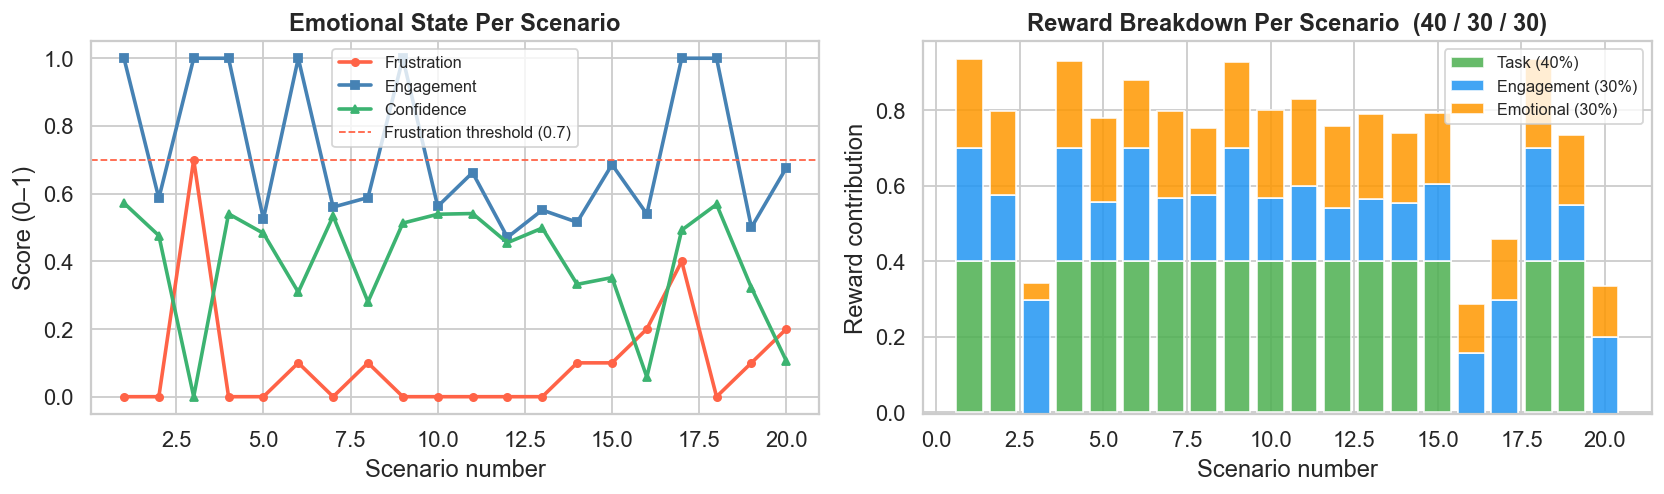

Saved -> /Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend/data/evaluation/figures/emotional_and_reward.pdf


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: frustration & engagement over time
ax = axes[0]
ax.plot(df_session['step'], df_session['frustration'],
        label='Frustration', color='tomato', linewidth=2, marker='o', markersize=4)
ax.plot(df_session['step'], df_session['engagement'],
        label='Engagement', color='steelblue', linewidth=2, marker='s', markersize=4)
ax.plot(df_session['step'], df_session['confidence'],
        label='Confidence', color='mediumseagreen', linewidth=2, marker='^', markersize=4)
ax.axhline(0.7, color='tomato', linestyle='--', linewidth=1,
           label='Frustration threshold (0.7)')
ax.set_xlabel('Scenario number')
ax.set_ylabel('Score (0–1)')
ax.set_title('Emotional State Per Scenario', fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

# Right: stacked reward breakdown
ax = axes[1]
ax.bar(df_session['step'], df_session['reward_task'],
       label='Task (40%)', color='#4CAF50', alpha=0.85)
ax.bar(df_session['step'], df_session['reward_engagement'],
       bottom=df_session['reward_task'],
       label='Engagement (30%)', color='#2196F3', alpha=0.85)
ax.bar(df_session['step'], df_session['reward_emotion'],
       bottom=df_session['reward_task'] + df_session['reward_engagement'],
       label='Emotional (30%)', color='#FF9800', alpha=0.85)
ax.set_xlabel('Scenario number')
ax.set_ylabel('Reward contribution')
ax.set_title('Reward Breakdown Per Scenario  (40 / 30 / 30)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'emotional_and_reward.png')
fig.savefig(FIGURES_DIR / 'emotional_and_reward.pdf')
plt.show()
print(f'Saved -> {FIGURES_DIR}/emotional_and_reward.pdf')

## 9. Step-by-Step Decision Table


In [8]:
df_session['rolling_success'] = (
    df_session['task_completed']
    .rolling(5, min_periods=1)
    .mean()
    .round(2)
)

def delta_arrow(d):
    if d > 0:  return f'↑ +{d}'
    if d < 0:  return f'↓ {d}'
    return  '->  0'

display_df = pd.DataFrame({
    'Step'            : df_session['step'],
    'Scenario'        : df_session['scenario'].str.replace('_', ' ').str.title(),
    'Difficulty'      : df_session['difficulty'],
    'Δ Difficulty'    : df_session['difficulty_delta'].apply(delta_arrow),
    'Completed'       : df_session['task_completed'].map({True: '✓', False: '✗'}),
    'Frustration'     : df_session['frustration'].round(2),
    'Engagement'      : df_session['engagement'].round(2),
    'Rolling success' : df_session['rolling_success'],
    'Reward'          : df_session['reward'].round(3),
})

display_df.set_index('Step', inplace=True)
display_df

,Scenario,Difficulty,Δ Difficulty,Completed,Frustration,Engagement,Rolling success,Reward
Step,,,,,,,,
1,Emotion Recognition,3,-> 0,✓,0.0,1.00,1.00,0.933
2,Sharing,4,↑ +1,✓,0.0,0.59,1.00,0.794
3,Emotion Recognition,5,↑ +1,✗,0.7,1.00,0.67,0.341
4,Emotion Recognition,5,-> 0,✓,0.0,1.00,0.75,0.928
5,Sharing,5,-> 0,✓,0.0,0.53,0.80,0.777
6,Emotion Recognition,5,↑ +1,✓,0.1,1.00,0.80,0.878
7,Sharing,5,↑ +1,✓,0.0,0.56,0.80,0.795
8,Sharing,5,↑ +1,✓,0.1,0.59,1.00,0.751
9,Emotion Recognition,5,↑ +1,✓,0.0,1.00,1.00,0.924


## 10. Policy Decision Heatmap

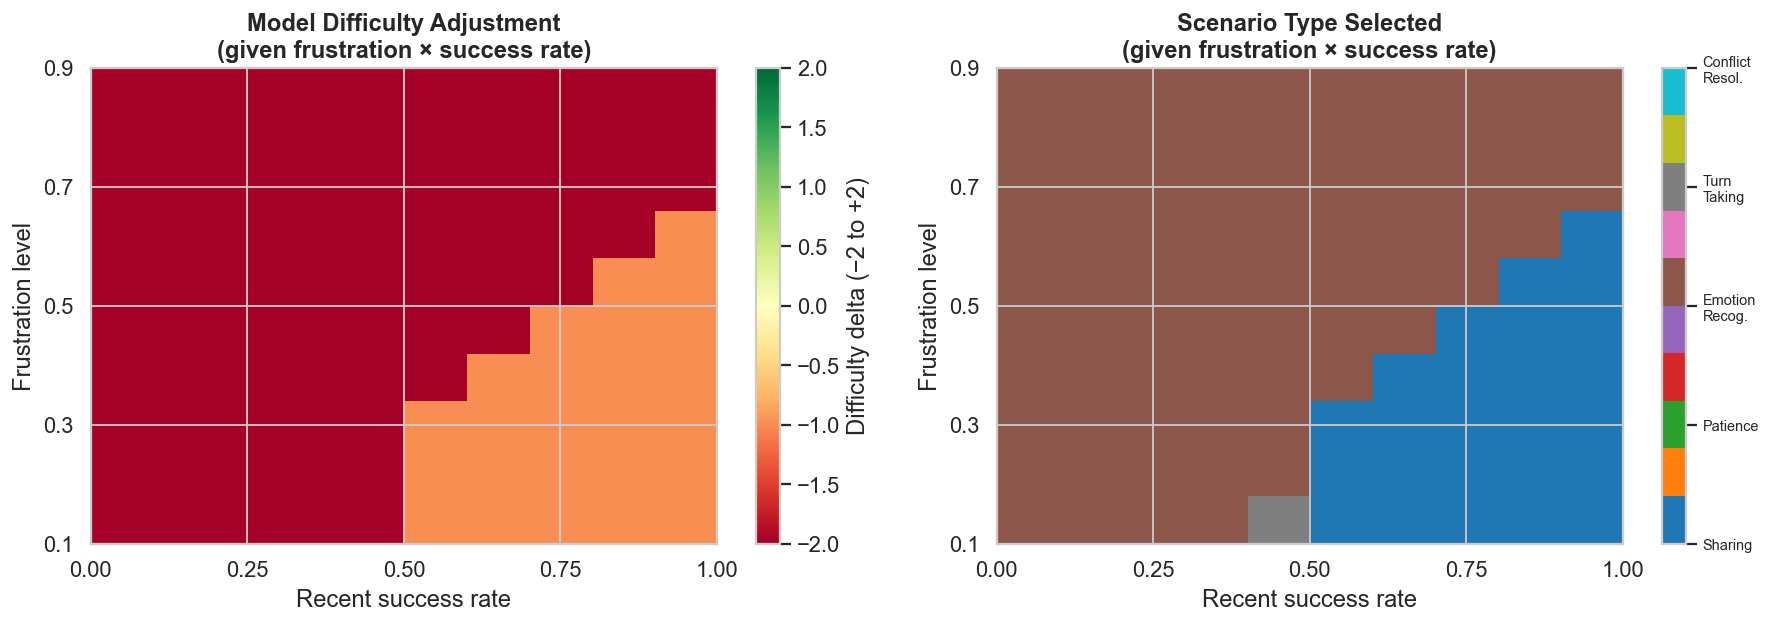

Saved /Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend/data/evaluation/figures/policy_heatmap.pdf


In [9]:
from app.rl.state_builder import (
    build_state_vector, build_context_features,
    build_performance_features, build_emotion_features,
    build_game_theory_features,
)

GRID_SIZE = 10
frustration_vals    = np.linspace(0.1, 0.9, GRID_SIZE)
success_rate_vals   = np.linspace(0.0, 1.0, GRID_SIZE)

# Use the first test profile's features as a constant background
profile_features = test_profiles[PROFILE_IDX].to_profile_features()

delta_grid = np.zeros((GRID_SIZE, GRID_SIZE))
scenario_grid = [[""] * GRID_SIZE for _ in range(GRID_SIZE)]

for fi, frust in enumerate(frustration_vals):
    for si, success_rate in enumerate(success_rate_vals):
        # Derive engagement as inverse of frustration (simplified)
        engagement = max(0.0, 1.0 - frust * 0.8)
        confidence = success_rate * 0.7 + 0.15  # rough proxy

        context   = build_context_features(
            difficulty=3, scenario_type_idx=0, step=10,
            session_time=100.0, reinforcement_idx=0,
            complexity_idx=0, last_action_idx=0, max_steps=100,
        )
        perf      = build_performance_features(
            last_5_success=[round(success_rate)] * 5,
            rolling_success=success_rate,
            avg_completion=20.0,
            scenarios_completed=10,
            streak=int((success_rate - 0.5) * 4),
            improvement=success_rate - 0.5,
        )
        emotion   = build_emotion_features(
            frustration=frust, engagement=engagement, confidence=confidence,
            prev_frustration=frust, prev_engagement=engagement, prev_confidence=confidence,
        )
        game_th   = build_game_theory_features(
            cooperation=0.5, risk=0.5, fairness=0.5, trust=0.5, reciprocity=0.5,
        )
        state     = build_state_vector(profile_features, context, perf, emotion, game_th)

        obs_norm  = train_env.normalize_obs(state.reshape(1, -1)).flatten()
        act, _    = model.predict(obs_norm.reshape(1, -1), deterministic=True)
        decoded   = decode_action(int(act[0]) if hasattr(act, '__len__') else int(act))

        delta_grid[fi, si]    = decoded['difficulty_delta']
        scenario_grid[fi][si] = decoded['action_type']

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: difficulty delta heatmap
ax = axes[0]
im = ax.imshow(delta_grid, aspect='auto', origin='lower',
               cmap='RdYlGn', vmin=-2, vmax=2,
               extent=[0, 1, 0.1, 0.9])
fig.colorbar(im, ax=ax, label='Difficulty delta (−2 to +2)')
ax.set_xlabel('Recent success rate')
ax.set_ylabel('Frustration level')
ax.set_title('Model Difficulty Adjustment\n(given frustration × success rate)',
             fontweight='bold')
ax.set_xticks(np.linspace(0, 1, 5))
ax.set_yticks(np.linspace(0.1, 0.9, 5))

# Right: scenario type chosen for each cell
ax2 = axes[1]
type_to_int = {t: i for i, t in enumerate(ACTION_SPACE_CONFIG['action_types'])}
scenario_int_grid = np.array([[type_to_int[scenario_grid[fi][si]]
                                for si in range(GRID_SIZE)]
                               for fi in range(GRID_SIZE)])
im2 = ax2.imshow(scenario_int_grid, aspect='auto', origin='lower',
                 cmap='tab10', vmin=0, vmax=4,
                 extent=[0, 1, 0.1, 0.9])
cbar2 = fig.colorbar(im2, ax=ax2, ticks=range(5))
cbar2.ax.set_yticklabels(['Sharing', 'Patience', 'Emotion\nRecog.', 'Turn\nTaking', 'Conflict\nResol.'],
                          fontsize=8)
ax2.set_xlabel('Recent success rate')
ax2.set_ylabel('Frustration level')
ax2.set_title('Scenario Type Selected\n(given frustration × success rate)',
              fontweight='bold')
ax2.set_xticks(np.linspace(0, 1, 5))
ax2.set_yticks(np.linspace(0.1, 0.9, 5))

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'policy_heatmap.png')
fig.savefig(FIGURES_DIR / 'policy_heatmap.pdf')
plt.show()
print(f'Saved {FIGURES_DIR}/policy_heatmap.pdf')

## 11. Multi-Profile Comparison

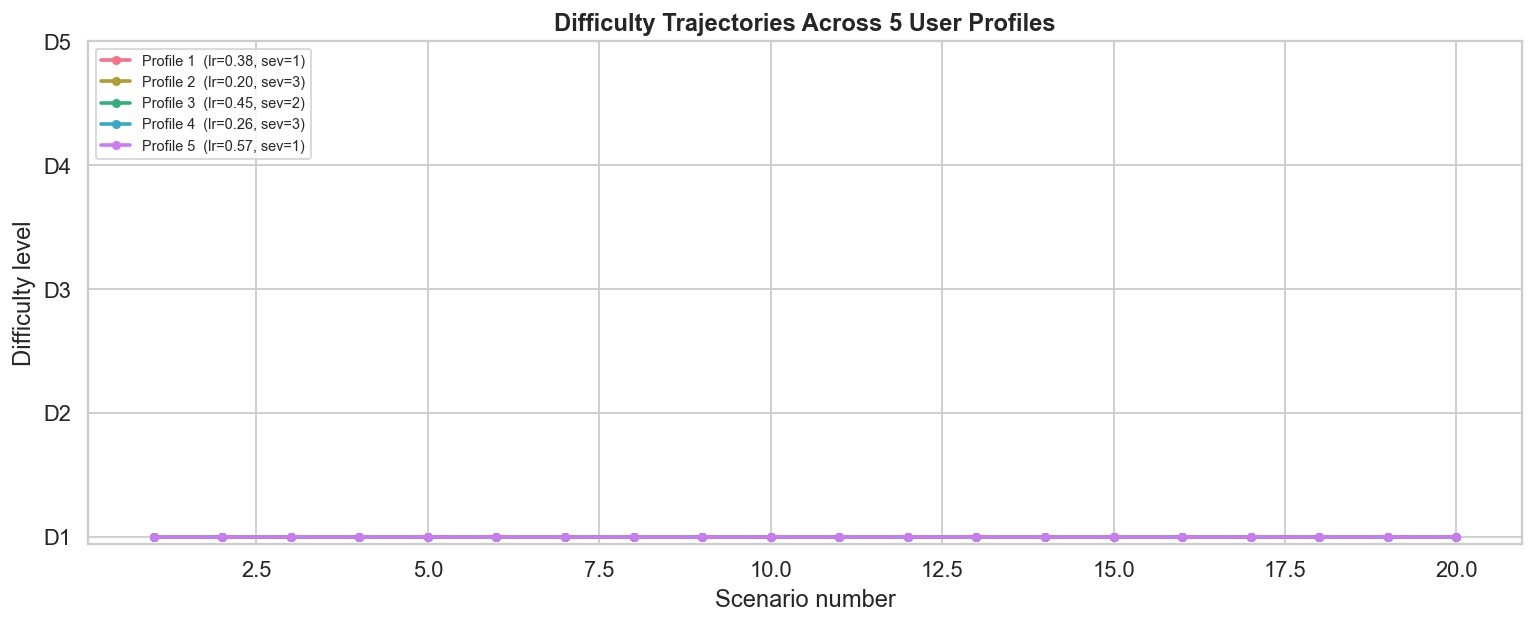

  Profile  Age  Severity  Learning rate  Frust. tolerance Success rate  Final diff.
Profile 1  6.9         1           0.38              0.23        80.0%            1
Profile 2  6.9         3           0.20              0.12        35.0%            1
Profile 3  9.5         2           0.45              0.39        60.0%            1
Profile 4  6.3         3           0.26              0.31        35.0%            1
Profile 5  6.3         1           0.57              0.19        90.0%            1

Saved /Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend/data/evaluation/figures/multi_profile_trajectories.pdf


In [10]:
N_PROFILES = min(5, len(test_profiles))
N_STEPS_MP = 20
palette = sns.color_palette('husl', N_PROFILES)

fig, ax = plt.subplots(figsize=(12, 5))

profile_summaries = []
for pi in range(N_PROFILES):
    p = test_profiles[pi]
    env_mp = ASDInterventionEnv(p, seed=SEED + pi)
    obs_mp, _ = env_mp.reset()
    diffs_mp = []
    completed_mp = []
    for _ in range(N_STEPS_MP):
        obs_norm = train_env.normalize_obs(obs_mp.reshape(1, -1)).flatten()
        act, _   = model.predict(obs_norm.reshape(1, -1), deterministic=True)
        obs_mp, _, term, trunc, info = env_mp.step(
            int(act[0]) if hasattr(act, '__len__') else int(act)
        )
        diffs_mp.append(env_mp._current_difficulty)
        completed_mp.append(info['task_completed'])
        if term or trunc:
            break

    label = (f'Profile {pi+1}  '
             f'(lr={p.learning_rate:.2f}, '
             f'sev={p.severity})')
    ax.plot(range(1, len(diffs_mp)+1), diffs_mp,
            color=palette[pi], linewidth=2, marker='o',
            markersize=4, label=label)
    profile_summaries.append({
        'Profile'         : f'Profile {pi+1}',
        'Age'             : round(p.age, 1),
        'Severity'        : p.severity,
        'Learning rate'   : round(p.learning_rate, 2),
        'Frust. tolerance': round(p.frustration_tolerance, 2),
        'Success rate'    : f'{np.mean(completed_mp):.1%}',
        'Final diff.'     : diffs_mp[-1] if diffs_mp else '—',
    })

ax.set_yticks(range(1, 6))
ax.set_yticklabels(['D1', 'D2', 'D3', 'D4', 'D5'])
ax.set_xlabel('Scenario number')
ax.set_ylabel('Difficulty level')
ax.set_title('Difficulty Trajectories Across 5 User Profiles', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'multi_profile_trajectories.png')
fig.savefig(FIGURES_DIR / 'multi_profile_trajectories.pdf')
plt.show()

print(pd.DataFrame(profile_summaries).to_string(index=False))
print(f'\nSaved {FIGURES_DIR}/multi_profile_trajectories.pdf')

## 12. Export All Figures

In [11]:
print('=== Generated Figures ===')
for f in sorted(FIGURES_DIR.glob('*.pdf')):
    size_kb = f.stat().st_size // 1024
    print(f'  {f.name:<45}  ({size_kb} KB)')

print(f'\nAll figures saved to: {FIGURES_DIR}')

=== Generated Figures ===
  difficulty_trajectory.pdf                      (25 KB)
  emotional_and_reward.pdf                       (29 KB)
  multi_profile_trajectories.pdf                 (24 KB)
  policy_heatmap.pdf                             (31 KB)
  training_curves.pdf                            (32 KB)

All figures saved to: /Users/darren/Documents/MTU/Thesis/asd-intervention-thesis/backend/data/evaluation/figures
